# Finding and using the scarcest measurements in the NCI portfolio

**Level:** intermediate &nbsp;·&nbsp; **Language:** Python &nbsp;·&nbsp; **Runtime:** about a minute
&nbsp;·&nbsp; **Access:** none required - the Proteomic Data Commons is fully open

Everyone knows where to find cancer RNA sequencing. Almost nobody knows that the NCI
portfolio contains ubiquitylome data on five studies, lipidomics on three, and a single
cohort measured seven different ways including protein-protein interactions.

This workbook enumerates the entire Proteomic Data Commons through its public GraphQL
API, ranks analytical fractions by scarcity, and finds the cohorts where several scarce
layers land on the same tumors. No account, no key, no data access request.

In [1]:
import json
from collections import Counter, defaultdict
from urllib.request import Request, urlopen

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

PDC = "https://proteomic.datacommons.cancer.gov/graphql"

QUERY = """
{
  allPrograms {
    name
    projects {
      name
      studies {
        pdc_study_id
        submitter_id_name
        analytical_fraction
        experiment_type
        cases_count
      }
    }
  }
}
"""


def pdc_query(query: str) -> dict:
    req = Request(
        PDC,
        data=json.dumps({"query": query}).encode(),
        headers={"Content-Type": "application/json"},
    )
    with urlopen(req, timeout=180) as r:  # noqa: S310 - fixed, trusted host
        return json.loads(r.read().decode())


data = pdc_query(QUERY)["data"]

rows = []
for prog in data["allPrograms"]:
    for proj in prog.get("projects") or []:
        for st in proj.get("studies") or []:
            rows.append(
                {
                    "program": prog["name"],
                    "project": proj["name"],
                    "pdc_study_id": st.get("pdc_study_id"),
                    "study": st.get("submitter_id_name"),
                    "fraction": st.get("analytical_fraction"),
                    "experiment": st.get("experiment_type"),
                    "cases": st.get("cases_count") or 0,
                }
            )

df = pd.DataFrame(rows)
print(f"{len(df)} studies across {df['program'].nunique()} programs")

255 studies across 9 programs


## 1. Which measurements are actually scarce?

In [2]:
scarcity = (
    df.groupby("fraction")
    .agg(n_studies=("pdc_study_id", "nunique"), total_cases=("cases", "sum"))
    .sort_values("n_studies")
)
print(scarcity.to_string())

SCARCE = set(scarcity[scarcity["n_studies"] <= 20].index)
print(f"\nScarce fractions (20 or fewer studies): {sorted(SCARCE)}")

                             n_studies  total_cases
fraction                                           
Protein-Protein interaction          1          153
Lipidome                             3          263
Ubiquitylome                         5          520
Metabolome                           7          602
Glycoproteome                       16         1823
Acetylome                           19         1487
Phosphoproteome                     95         6958
Proteome                           109         7826

Scarce fractions (20 or fewer studies): ['Acetylome', 'Glycoproteome', 'Lipidome', 'Metabolome', 'Protein-Protein interaction', 'Ubiquitylome']


Proteome and phosphoproteome are common. Acetylome, glycoproteome, ubiquitylome,
metabolome, lipidome and protein-protein interaction are not, and a researcher who
needs one of them has very few places to go.

## 2. Which cohorts carry several scarce layers on the same tumors?

PDC ships one study per analytical fraction, so the proteome and the ubiquitylome of
the same tumors arrive as separate records. Grouping them back into cohorts is what
reveals where deep multi-layer analysis is actually possible.

In [3]:
import re

FRACTION_SUFFIX = re.compile(
    r"\s*[-]\s*(?:DIA\s+|TMT\s+|Label\s*Free\s+)?(?:Intact\s+|N-linked\s+|Cyst\s+Fluid\s+)?"
    r"(?:CompRef\s+)?(?:Proteome|Phosphoproteome|Phosphotyrosine|Acetylome|Glycoproteome|"
    r"Glycosite-containing\s+peptide|Ubiquitylome|Metabolome|Lipidome|"
    r"Protein-protein\s+Interaction|Proteomics)\s*$",
    re.IGNORECASE,
)


def cohort_name(study: str) -> str:
    name = (study or "").strip()
    for _ in range(3):
        stripped = FRACTION_SUFFIX.sub("", name).strip(" -")
        if stripped == name:
            break
        name = stripped
    return name


# CompRef studies are inter-laboratory reference materials, not patient cohorts.
patients = df[~df["study"].str.contains("CompRef", case=False, na=False)].copy()
patients["cohort"] = patients["study"].map(cohort_name)

grouped = (
    patients.groupby("cohort")
    .agg(
        n_fractions=("fraction", "nunique"),
        fractions=("fraction", lambda s: ", ".join(sorted(set(s)))),
        max_cases=("cases", "max"),
    )
    .reset_index()
)
grouped["n_scarce"] = patients.groupby("cohort")["fraction"].apply(
    lambda s: len(set(s) & SCARCE)
).values

deep = grouped[grouped["n_scarce"] >= 2].sort_values(
    ["n_scarce", "max_cases"], ascending=False
)
print(f"{len(grouped)} cohorts; {len(deep)} carry two or more scarce layers\n")
print(deep.head(12)[["cohort", "max_cases", "n_fractions", "n_scarce", "fractions"]].to_string(index=False))

130 cohorts; 10 carry two or more scarce layers

                       cohort  max_cases  n_fractions  n_scarce                                                                                                  fractions
             CPTAC STAD Study        193            7         5 Acetylome, Glycoproteome, Metabolome, Phosphoproteome, Protein-Protein interaction, Proteome, Ubiquitylome
              CPTAC AML Study        164            6         4                                  Acetylome, Glycoproteome, Lipidome, Metabolome, Phosphoproteome, Proteome
 CPTAC GBM Confirmatory Study        118            6         4                                  Acetylome, Glycoproteome, Lipidome, Metabolome, Phosphoproteome, Proteome
    CPTAC GBM Discovery Study        111            5         3                                                 Acetylome, Lipidome, Metabolome, Phosphoproteome, Proteome
CPTAC UCEC Confirmatory Study        159            4         2                                 

## 3. Pick a target and check the layer overlap

The trap in multi-omic work is assuming all layers cover all cases. They do not.

In [4]:
TARGET = deep.iloc[0]["cohort"] if len(deep) else patients["cohort"].iloc[0]
print(f"Target cohort: {TARGET}\n")

target = patients[patients["cohort"] == TARGET][
    ["pdc_study_id", "fraction", "experiment", "cases"]
].sort_values("cases", ascending=False)
print(target.to_string(index=False))

n_max = int(target["cases"].max())
n_min = int(target["cases"].min())
print(f"\nlargest layer  : {n_max} cases")
print(f"smallest layer : {n_min} cases")
print(f"complete-case analysis across every layer is bounded above by {n_min} cases")
print(f"  -> that is {100 * n_min / n_max:.0f}% of the largest layer")

Target cohort: CPTAC STAD Study

pdc_study_id                    fraction experiment  cases
   PDC000622                   Acetylome      TMT18    193
   PDC000616               Glycoproteome      TMT18    193
   PDC000615             Phosphoproteome      TMT18    193
   PDC000614                    Proteome      TMT18    193
   PDC000621                  Metabolome Label Free    187
   PDC000617                Ubiquitylome Label Free    184
   PDC000626 Protein-Protein interaction      TMT10    153

largest layer  : 193 cases
smallest layer : 153 cases
complete-case analysis across every layer is bounded above by 153 cases
  -> that is 79% of the largest layer


In [5]:
# One house style for every figure below: a single accent, one contrast colour for the
# thing the reader must not miss, and nothing else. Defined here rather than imported so
# the downloaded notebook runs on its own.
INK, ACCENT, WARN, MUTED = "#1f2430", "#2f6f6b", "#b4762a", "#9aa3b2"
mpl.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 120,
        "font.size": 9.5,
        "axes.titlesize": 11,
        "axes.titleweight": "semibold",
        "axes.labelcolor": INK,
        "axes.titlecolor": INK,
        "text.color": INK,
        "axes.edgecolor": MUTED,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "axes.grid": True,
        "grid.color": "#e6e9ef",
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
    }
)


def finish(ax, title):
    ax.set_title(title, loc="left")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.figure.tight_layout()
    return ax

### Where the complete-case cohort actually stops

Each bar is one measured layer. The dashed line is the smallest of them, and it is the
real ceiling on any analysis that needs every layer at once - usually far to the left
of the cohort size the portal advertises.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


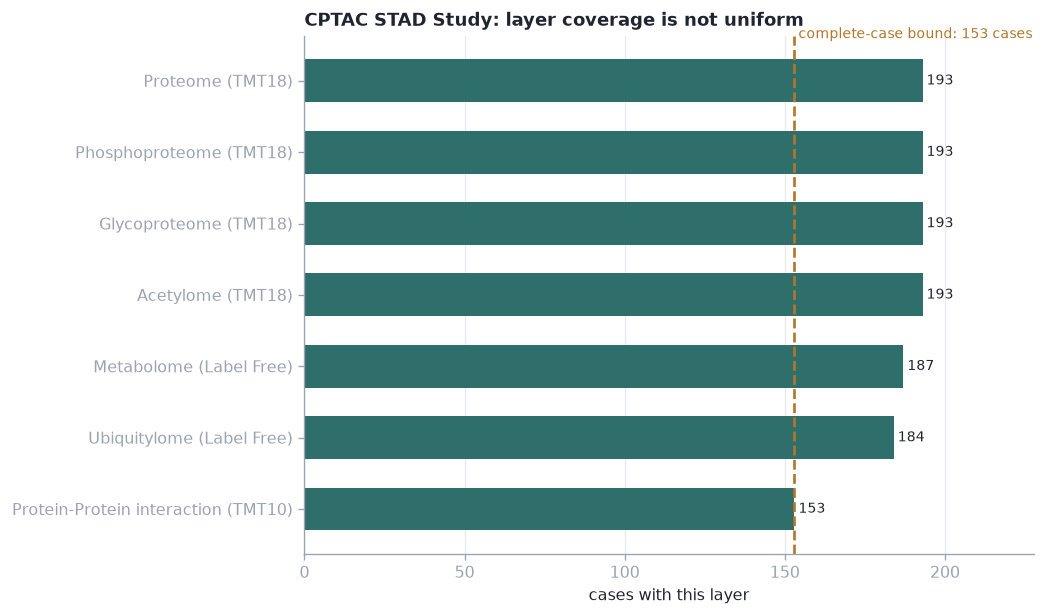

In [6]:
ordered = target.sort_values("cases")
# One row per study, not per fraction: a cohort can carry the same analytical fraction
# twice under different experiment types, so the bars sit on numeric positions and the
# labels name both. Plotting against the fraction alone silently merges those rows.
pos = list(range(len(ordered)))
fig, ax = plt.subplots(figsize=(8.8, 0.46 * len(ordered) + 2.0))
ax.barh(pos, ordered["cases"], color=ACCENT, height=0.6)
ax.set_yticks(pos)
ax.set_yticklabels(
    [f"{f} ({e})" for f, e in zip(ordered["fraction"], ordered["experiment"], strict=True)]
)
ax.axvline(n_min, color=WARN, lw=1.6, ls="--")
# The bound sits wherever the smallest layer falls. Once that is far to the right the
# callout has no room left, so it flips to the inside of the line rather than running
# off the edge and being silently clipped.
flip = n_min > 0.7 * n_max * 1.18
bound = f"complete-case bound: {n_min} cases"
ax.text(n_min, len(ordered) - 0.35, f"{bound} " if flip else f" {bound}",
        color=WARN, fontsize=8.5, va="center", ha="right" if flip else "left")
for i, v in enumerate(ordered["cases"]):
    ax.text(v, i, f" {int(v)}", va="center", fontsize=8.5, color=INK)
ax.set_xlabel("cases with this layer")
ax.set_xlim(0, n_max * 1.18)
ax.grid(axis="y", visible=False)
finish(ax, f"{TARGET}: layer coverage is not uniform")
plt.show()

## 4. How much reuse do these scarce datasets get?

PDC study identifiers are almost never quoted in the literature, which means
citation-based reuse tracing is close to blind here. We can demonstrate that directly.

In [7]:
from urllib.parse import urlencode

EPMC = "https://www.ebi.ac.uk/europepmc/webservices/rest/search"


def epmc_hits(query: str) -> int:
    url = f"{EPMC}?{urlencode({'query': query, 'format': 'json', 'pageSize': 1})}"
    with urlopen(url, timeout=120) as r:  # noqa: S310 - fixed, trusted host
        return int(json.loads(r.read().decode()).get("hitCount") or 0)


print("Articles whose methods or results cite these PDC study accessions:\n")
checked = 0
for _, row in target.iterrows():
    sid = row["pdc_study_id"]
    n = epmc_hits(f'METHODS:"{sid}"')
    print(f"  {sid}  {row['fraction']:<28} {n} articles")
    checked += 1
    if checked >= 6:
        break

print(
    "\nNear-zero counts here do not mean the data are unused. They mean authors cite the\n"
    "marker paper rather than the accession, so citation-based reuse tracing cannot see\n"
    "proteomic reuse at all. That is a finding about the citation practice, not the data."
)

Articles whose methods or results cite these PDC study accessions:



  PDC000622  Acetylome                    1 articles


  PDC000616  Glycoproteome                1 articles


  PDC000615  Phosphoproteome              1 articles


  PDC000614  Proteome                     1 articles


  PDC000621  Metabolome                   1 articles


  PDC000617  Ubiquitylome                 1 articles

Near-zero counts here do not mean the data are unused. They mean authors cite the
marker paper rather than the accession, so citation-based reuse tracing cannot see
proteomic reuse at all. That is a finding about the citation practice, not the data.


## What to do with this

- The cohort identified above is the most deeply measured in the NCI portfolio, and all
  of it downloads without an account.
- **Retrieve clinical data separately.** PDC ships no outcome, treatment or demographic
  variables. For CPTAC cohorts these live in the Genomic Data Commons and must be joined
  on case identifier - the step where most CPTAC reuse stalls.
- **Check the layer intersection before designing**, using the numbers printed above.